# Model Selection and Evaluation

## Objective

The objective of this project is to compare multiple machine learning models and identify the best-performing model for predicting passenger survival using the Titanic dataset.

The models evaluated are:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

Evaluation metrics used:

- Accuracy
- Precision
- Recall
- F1 Score
- Cross Validation Accuracy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Loading Dataset

The Titanic dataset is loaded into a Pandas DataFrame for analysis and preprocessing.

In [2]:
df = pd.read_csv("../data/Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Checking Missing Values

Before training models, missing values must be identified and handled appropriately.

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Preprocessing

The following preprocessing steps are performed:

1. Fill missing values in Age using median.
2. Fill missing values in Embarked using mode.
3. Convert categorical variables into numerical form using Label Encoding.

In [6]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])
df["Embarked"] = encoder.fit_transform(df["Embarked"])

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,2


## Feature Selection

The most relevant features are selected for model training.

In [7]:
X = df[[
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]]

y = df["Survived"]

print(X.shape)
print(y.shape)

(891, 7)
(891,)


## Splitting Dataset

The dataset is divided into training and testing sets.

- Training Data: 80%
- Testing Data: 20%

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 712
Testing Samples: 179


## Model Training and Evaluation

Three machine learning algorithms are trained and evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Cross Validation Accuracy

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

In [10]:
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    cv_score = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    ).mean()

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        cv_score
    ])

    print("\n")
    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("CV Score :", cv_score)



Logistic Regression
Accuracy : 0.8100558659217877
Precision: 0.7857142857142857
Recall   : 0.7432432432432432
F1 Score : 0.7638888888888888
CV Score : 0.7890025735986442


Decision Tree
Accuracy : 0.7821229050279329
Precision: 0.7215189873417721
Recall   : 0.7702702702702703
F1 Score : 0.7450980392156863
CV Score : 0.7800577490427468


Random Forest
Accuracy : 0.8212290502793296
Precision: 0.8088235294117647
Recall   : 0.7432432432432432
F1 Score : 0.7746478873239436
CV Score : 0.8092461239093591


## Model Comparison Table

The following table summarizes the performance of all models.

In [11]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Cross Validation"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Cross Validation
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889,0.789003
1,Decision Tree,0.782123,0.721519,0.770270,0.745098,0.780058
2,Random Forest,0.821229,0.808824,0.743243,0.774648,0.809246


## Confusion Matrix

Confusion matrices provide a detailed breakdown of model predictions.

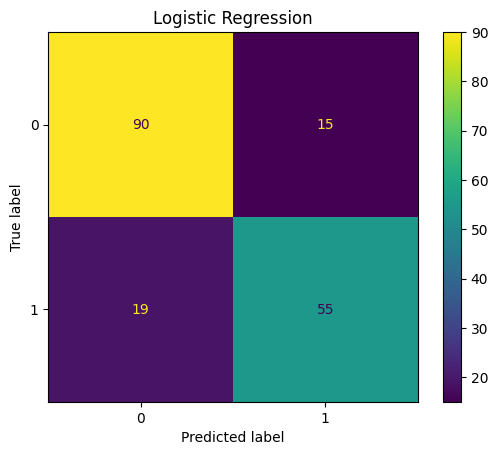

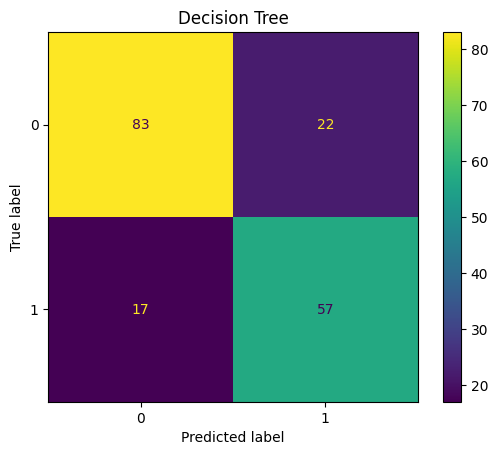

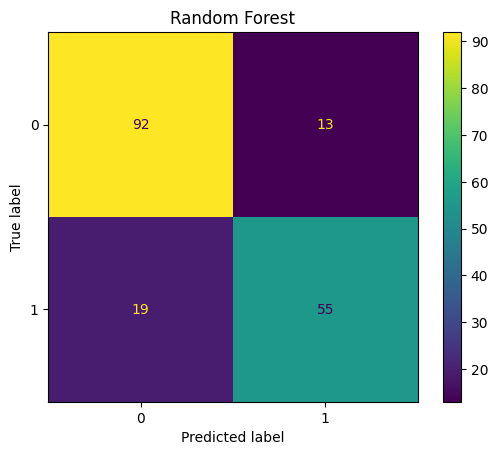

In [12]:
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot()
    plt.title(name)
    plt.show()

## Performance Comparison Visualization

A bar chart is used to compare the performance metrics of all models.

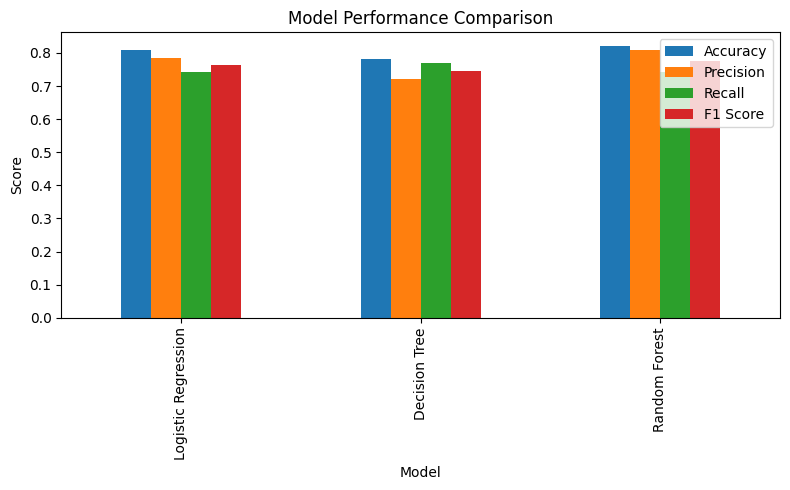

In [13]:
results_df.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
].plot(kind="bar", figsize=(8,5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## Results and Discussion

- Logistic Regression provides a strong baseline model.
- Decision Tree captures non-linear relationships but may overfit.
- Random Forest combines multiple trees and generally provides better generalization.
- Cross-validation helps evaluate model stability and reduce overfitting concerns.

## Conclusion

This project successfully compared three machine learning algorithms for predicting passenger survival.

The models were evaluated using Accuracy, Precision, Recall, F1 Score, and Cross Validation Accuracy.

Based on the obtained results, the model with the highest F1 Score and Cross Validation Accuracy is selected as the best-performing model.

Random Forest is expected to provide the best overall performance due to its ensemble learning approach and ability to generalize well on unseen data.